In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
dataset=pd.read_csv('Social_Network_Ads.csv')
X=dataset.iloc[:,:-1].values
y=dataset.iloc[:,-1].values

In [4]:
from sklearn.model_selection import  train_test_split
x_train,x_test, y_train,y_test= train_test_split(X,y,test_size=0.25, random_state=0)

In [5]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()


x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)




In [ ]:
x_train

In [7]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(criterion="entropy",  random_state=0)
clf.fit(x_train, y_train)


DecisionTreeClassifier(criterion='entropy', random_state=0)

In [8]:
y_prect=clf.predict(x_test)
print(y_test)
print(y_prect)
print(np.concatenate((y_prect.reshape(len(y_prect), 1),(y_test.reshape(len(y_test), 1))),1 ))

[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 1 0 0 1
 0 0 0 0 1 1 1 0 0 0 1 1 0 1 1 0 0 1 0 0 0 1 0 1 1 1]
[0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 1 1 1 0 0 1 0 0 1 0 1 0 1 0 0 0 1 1 0 0 1
 0 0 0 0 1 1 1 1 0 0 1 0 0 1 1 0 0 1 0 0 0 1 0 1 1 1]
[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [1 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 0]
 [0 0]
 [0 0]
 [1 

In [18]:
clf.predict(sc.transform([[30,87000]]))

array([0])

In [19]:
classifier=clf

In [20]:
print(list(dataset.columns))

['Age', 'EstimatedSalary', 'Purchased']


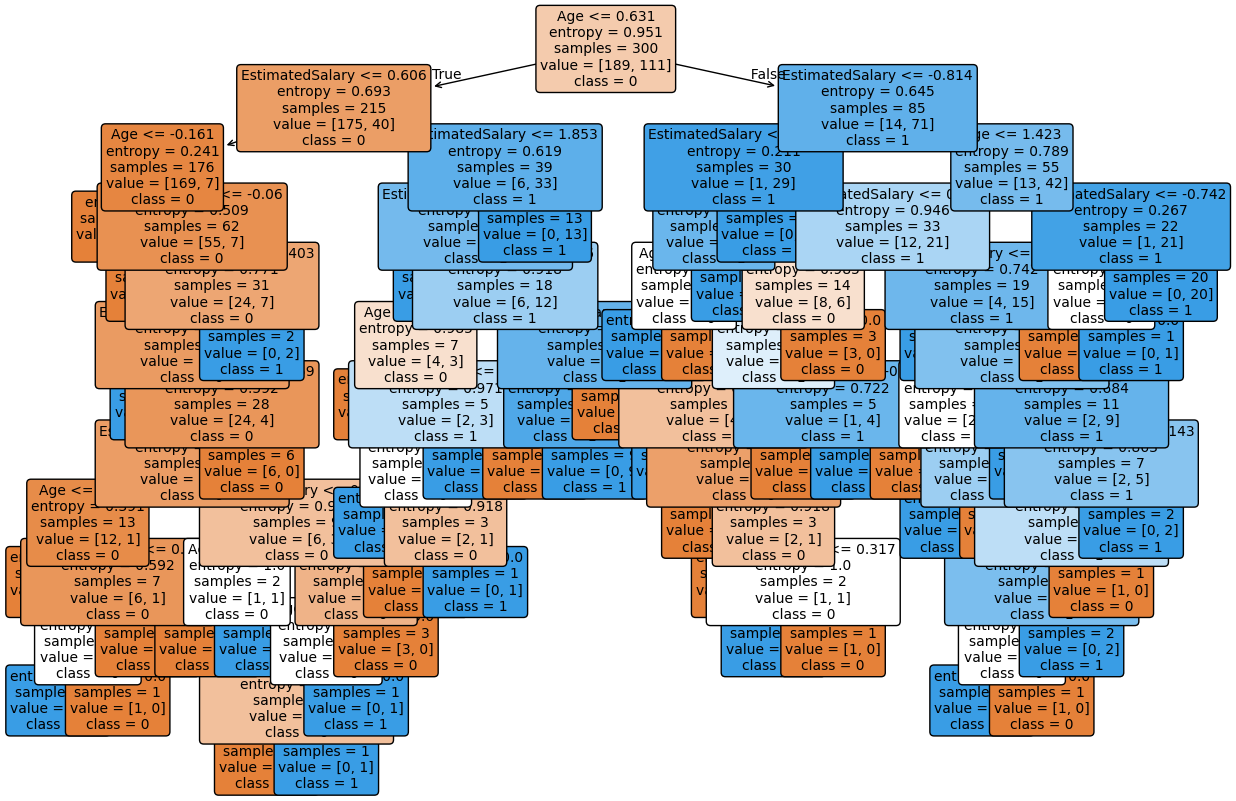

In [21]:
# 2. Plot the tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
plt.figure(figsize=(15, 10))
plot_tree(
    clf,
    feature_names=list(dataset.columns),
    class_names=["0", "1"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay , accuracy_score
cnfm=confusion_matrix(y_test, y_prect)
ascore = accuracy_score(y_test, y_prect)
print(ascore)
cnfm

0.91


array([[62,  6],
       [ 3, 29]])

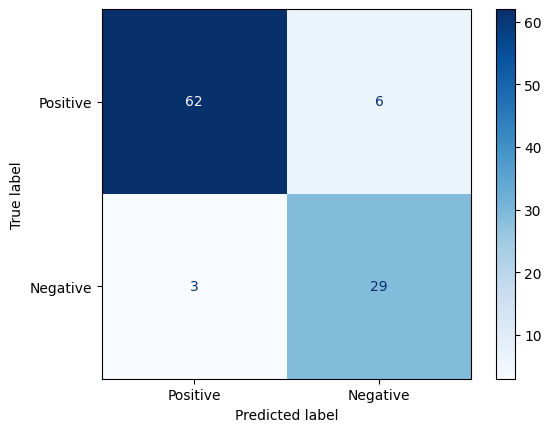

In [11]:
disp = ConfusionMatrixDisplay(confusion_matrix=cnfm, display_labels=[ 'Positive', 'Negative'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

### Trainning set Visulization


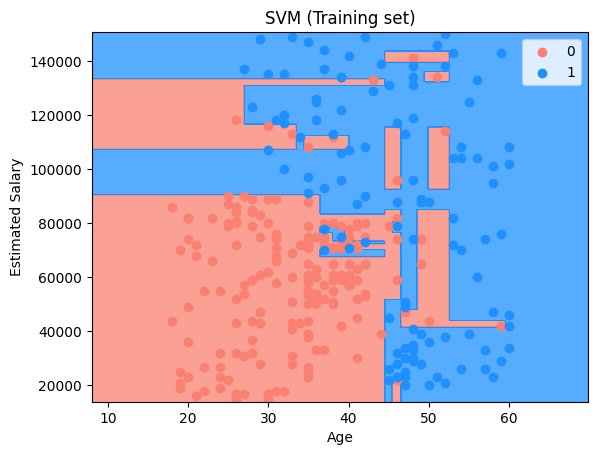

In [12]:
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt

X_set, y_set = sc.inverse_transform(x_train), y_train

# FIX: Create distinct step sizes based on feature scales (aiming for ~300 to 500 steps per axis)
x1_range = (X_set[:, 0].max() + 10) - (X_set[:, 0].min() - 10)
x2_range = (X_set[:, 1].max() + 1000) - (X_set[:, 1].min() - 1000)

step_x1 = x1_range / 400
step_x2 = x2_range / 400

# Generate the grid safely
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = step_x1),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = step_x2))

# Plot the decision boundary
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(['#FA8072', '#1E90FF']))

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# Plot the data points
# FIX: Reshape the color array to prevent Matplotlib scatter warnings
colors = ['#FA8072', '#1E90FF']
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = np.array([colors[i]]), label = j)

plt.title('SVM (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()


## Visualising the Test set results

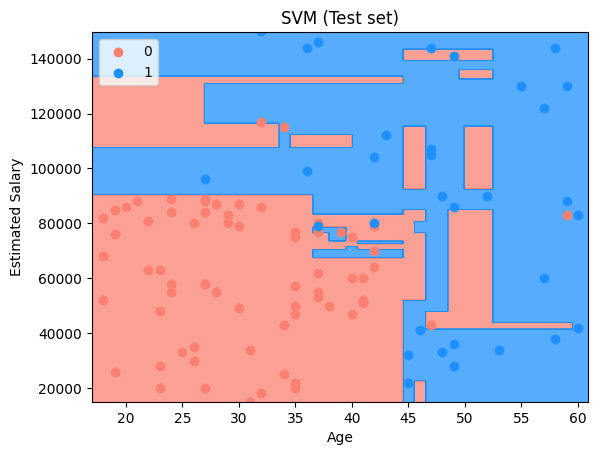

In [13]:
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt

X_set, y_set = sc.inverse_transform(x_test), y_test

# FIX: Calculate dynamic step sizes aiming for ~400 steps across each axis
x1_range = (X_set[:, 0].max() + 1) - (X_set[:, 0].min() - 1)
x2_range = (X_set[:, 1].max() + 1) - (X_set[:, 1].min() - 1)

step_x1 = x1_range / 400
step_x2 = x2_range / 400

# Create a safe, optimized grid of points
X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=step_x1),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=step_x2)
)

# Predict for each point on the grid
Z = classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape)

# Plot the decision boundary
plt.contourf(X1, X2, Z, alpha=0.75, cmap = ListedColormap(['#FA8072', '#1E90FF']))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# Define colors for scatter plot
colors = ['#FA8072', '#1E90FF']

# Plot the test set points (with minor structural fix for clean plotting array input)
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0], X_set[y_set == j, 1],
        c=np.array([colors[i]]), label=j
    )

# Add titles and labels
plt.title('SVM (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()
